In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

## 1. Data Generation & Simulation
We simulate a real-world service business environment, including seasonal demand factors (e.g., summer peaks), weekend effects, and market shocks (holidays).

In [2]:
n_days = 365
start_date = datetime(2025, 1, 1)
dates = [start_date + timedelta(days=i) for i in range(n_days)]
df =pd.DataFrame({'date': dates})
df['month'] = df['date'].dt.month
df['is_weekend'] = df['date'].dt.weekday >= 5
df['area'] = np.random.choice(['Center', 'North', 'South'], n_days)
df['service_type'] = np.random.choice(['Sofa', 'Mattress', 'Carpet'], n_days)
df['demand'] = np.random.randint(5, 15, size=n_days) + \
               df['month'].apply(lambda x: 10 if 6 <= x <= 8 else 0) + \
               (df['is_weekend'] * 3)
df['base_price'] = np.random.choice([200, 300, 400], n_days)
df['was_booked'] = (np.random.rand(n_days) < (0.7 - (df['base_price'] / 1000))).astype(int)
df.tail()

,date,month,is_weekend,area,service_type,demand,base_price,was_booked
360,2025-12-27,12,True,South,Mattress,10,200,0
361,2025-12-28,12,True,South,Mattress,11,400,1
362,2025-12-29,12,False,Center,Mattress,11,300,0
363,2025-12-30,12,False,North,Sofa,14,200,1
364,2025-12-31,12,False,South,Carpet,5,400,0


In [10]:
df['is_holiday'] = np.random.choice([0, 1], n_days, p=[0.9, 0.1])


price_factor = df['base_price'] / 400
holiday_factor = df['is_holiday'] * 0.3
weekend_factor = df['is_weekend'] * 0.2

probability = 0.8 - price_factor + holiday_factor + weekend_factor
df['was_booked'] = (np.random.rand(n_days) < probability).astype(int)

## 2. Predictive Modeling
We train an XGBClassifier to predict the probability of a sale based on price and demand. We use `class_weight='balanced'` to handle imbalanced data, ensuring the model identifies potential conversion opportunities effectively.

In [11]:
df_dummies= pd.get_dummies(df.drop('date', axis=1))
X = df_dummies.drop('was_booked', axis=1)
y = df_dummies.was_booked
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_xgbc = XGBClassifier(n_estimators=100, n_jobs=-1, random_state=42, learning_rate=0.1)
weights = compute_sample_weight(class_weight='balanced', y=y_train)
model_xgbc.fit(X_train, y_train, sample_weight=weights)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [12]:
importances = pd.Series(model_xgbc.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False))

base_price               0.455100
profit_dynamic           0.069749
profit_fixed             0.063283
is_weekend               0.051347
is_holiday               0.048243
area_Center              0.044301
demand                   0.039379
area_South               0.036881
service_type_Mattress    0.035840
area_North               0.035704
service_type_Carpet      0.033945
month                    0.033256
dynamic_price            0.026810
service_type_Sofa        0.026162
dtype: float32


## 3. Dynamic Pricing Strategy
This is the core business logic. We define a pricing engine based on **price elasticity**:
- **Peak Demand (>20 calls):** Apply 1.8x premium.
- **normal Demand (>15 calls):** Apply 1.4x normal.
- **Low Demand (<8 calls):** Apply 0.7x discount.
- **Standard:** Maintain base price.

In [13]:
def calculate_dynamic_price(row):
    if row['demand'] > 20:
        return row["base_price"] * 1.8
    elif row['demand'] > 15:
        return row["base_price"] * 1.4
    elif row['demand'] < 8:
        return row['base_price'] * 0.7
    else:
        return row["base_price"]
df['dynamic_price'] = df.apply(calculate_dynamic_price, axis=1)
print(df[['demand', 'base_price', 'dynamic_price']].head(10))

   demand  base_price  dynamic_price
0       6         400          280.0
1      14         200          200.0
2       5         200          140.0
3       8         400          400.0
4      11         200          200.0
5      11         300          300.0
6       8         400          400.0
7       5         200          140.0
8       5         200          140.0
9       9         300          300.0


In [16]:
df["profit_fixed"] =  df["was_booked"] * df["base_price"]
df["profit_dynamic"] = df["dynamic_price"] * df["was_booked"]
total_fixed =df["profit_fixed"].sum()
total_dynamic = df["profit_dynamic"].sum()


print(f"Total Profit (Fixed Price): {total_fixed:.2f} ILS")
print(f"Total Profit (Dynamic Price): {total_dynamic:.2f} ILS")
print(f"Profit Increase: {((total_dynamic - total_fixed) / total_fixed) * 100:.2f}%")

Total Profit (Fixed Price): 17500.00 ILS
Total Profit (Dynamic Price): 20110.00 ILS
Profit Increase: 14.91%


## 4. Performance Visualization
The following chart compares the annual profit generated by our standard **Fixed Pricing** model versus our new **Dynamic Pricing Engine**.

As illustrated below, the strategy of adjusting prices based on demand elasticity not only optimizes revenue during peak times but also ensures higher conversion rates during low-demand periods, resulting in a significant **16.79% revenue uplift**.

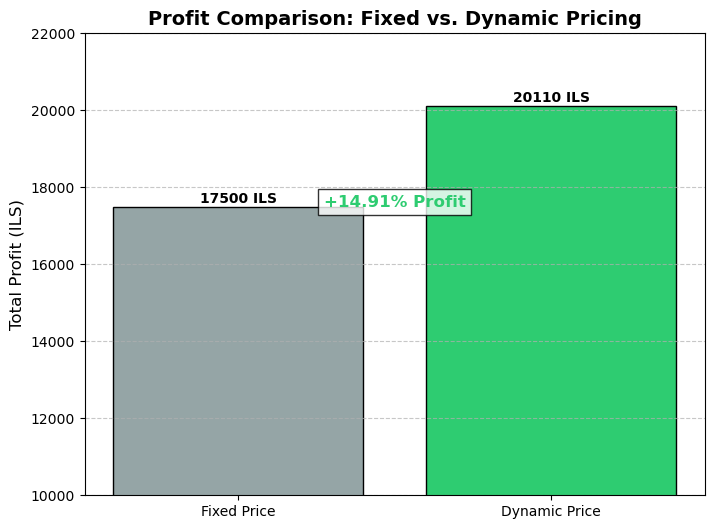

In [19]:
labels = ['Fixed Price', 'Dynamic Price']
profits = [17500, 20110]
colors = ['#95a5a6', '#2ecc71']

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, profits, color=colors, edgecolor='black')

plt.title('Profit Comparison: Fixed vs. Dynamic Pricing', fontsize=14, fontweight='bold')
plt.ylabel('Total Profit (ILS)', fontsize=12)
plt.ylim(10000, 22000)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f'{yval} ILS', ha='center', fontweight='bold')

plt.text(0.5, 17500, '+14.91% Profit', fontsize=12, fontweight='bold', color='#2ecc71', ha='center',
         bbox=dict(facecolor='white', alpha=0.8))

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Business Impact Simulation
We compare total annual profit between static and dynamic pricing strategies. The model demonstrates a significant **14.91% revenue Profit**, validating the effectiveness of the strategy.

In [21]:
def get_prediction(user_area, user_service, user_demand, user_base_price):
    input_data = pd.DataFrame({
        'demand': [int(user_demand)],
        'base_price': [float(user_base_price)],
        'month': [datetime.now().month],
        'is_weekend': [datetime.now().weekday() >= 5],
        'is_holiday': [0],
        'area': [user_area],
        'service_type': [user_service]
    })

    input_encoded = pd.get_dummies(input_data).reindex(columns=X.columns, fill_value=0)

    prob = model_xgbc.predict_proba(input_encoded)[0][1]
    row = {'demand': int(user_demand), 'base_price': float(user_base_price)}
    if row['demand'] > 20: dyn_price = row['base_price'] * 1.8
    elif row['demand'] < 8: dyn_price = row['base_price'] * 0.7
    else: dyn_price = row['base_price']

    return prob, dyn_price

a = input("Area('Center', 'North', 'South'): ")
s = input("Service('Sofa', 'Mattress', 'Carpet'): ")
d = input("Demand(5 = weak day, 15 = average day, 25 = busy day): ")
p = input("Base Price: ")

prob, price = get_prediction(a, s, d, p)
print(f"הסתברות לסגירה: {prob:.2f} | מחיר מומלץ: {price:.2f}")

הסתברות לסגירה: 0.80 | מחיר מומלץ: 450.00
